In [46]:
import pandas as pd
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import ast
from itertools import combinations
from collections import Counter, defaultdict
import re
from IPython.display import Image, display

In [2]:
url = "https://raw.githubusercontent.com/me9hanics/PainterPalette/main/datasets/artists.csv"
artists = pd.read_csv(url)

In [3]:
artists = artists.dropna(subset=['birth_year'])
print(artists.shape)

(9456, 30)


In [4]:
# split the artists into the century block that they belong
artists_14c = artists[(artists['birth_year'] >= 1300) & (artists['birth_year'] < 1400)]
artists_15c = artists[(artists['birth_year'] >= 1400) & (artists['birth_year'] < 1500)]
artists_16c = artists[(artists['birth_year'] >= 1500) & (artists['birth_year'] < 1600)]
artists_17c = artists[(artists['birth_year'] >= 1600) & (artists['birth_year'] < 1700)]
artists_18c = artists[(artists['birth_year'] >= 1700) & (artists['birth_year'] < 1800)]
artists_19c = artists[(artists['birth_year'] >= 1800) & (artists['birth_year'] < 1900)]
artists_20c = artists[(artists['birth_year'] >= 1900) & (artists['birth_year'] < 2100)] # also includes 21st-century artists since they are so sparse

In [5]:
# format is a list of dictionaries {city, date_ranges: [{start_year, end_year}, {start_year, end_year}], ...}
def parse_locations(location_str):
    locations = ast.literal_eval(location_str)
    result = []
    for item in locations:
        location, years_part = item.split(':')
        ranges = years_part.split(',')
        date_ranges = []
        for r in ranges:
            start_year, end_year = r.split('-')
            date_ranges.append({
                'start_year': int(start_year),
                'end_year': int(end_year)
            })
        result.append({
            'location': location,
            'date_ranges': date_ranges
        })
    return result

In [6]:
# for each century block, create a visualization based on geographic proximity
# color edges based on location and weighting to prioritize which shared location is used for coloring); consider years of the geographical proximity; weight the edges based on # of common years
def geo_proximity(artists):
  G = nx.Graph()
  
  # drop NA values
  artists = artists[artists['locations_with_years'].notna() & (artists['locations_with_years'] != '[]')]
  artists = artists[["artist", "locations_with_years"]]
  artists = artists.dropna()

  artists['locations_parsed'] = artists['locations_with_years'].apply(parse_locations)

  G.add_nodes_from(artists["artist"])

  # flatten table
  rows = []
  for _, artist_row in artists.iterrows():
      for loc in artist_row['locations_parsed']:
          for date_range in loc['date_ranges']:
              rows.append({
                  'artist': artist_row['artist'],
                  'location': loc['location'],
                  'start_year': date_range['start_year'],
                  'end_year': date_range['end_year']
              })

  df_flat = pd.DataFrame(rows)

  edges = {}
  for location, group in df_flat.groupby('location'):
      artist_rows = list(group.itertuples())
      for a1, a2 in combinations(artist_rows, 2):
          # check if time ranges overlap
          overlap_start = max(a1.start_year, a2.start_year)
          overlap_end = min(a1.end_year, a2.end_year)
          artist1, artist2 = a1.artist, a2.artist
          if overlap_start <= overlap_end and artist1 != artist2:
              # add edges between 2 artists in alphabetical order of the artists
              if artist1 < artist2:
                if (artist1, artist2) in edges:
                  # edges keep weight and locations attributes, where locations keeps a dictionary of locations to weights/num overlapping years
                  edges[(artist1, artist2)]['weight'] += weight
                  edge_locations = edges[(artist1, artist2)]['locations']
                  if location in edge_locations:
                    edge_locations[location] += weight
                  else:
                    edge_locations[location] = weight
                else:
                  weight = overlap_end - overlap_start + 1
                  edges[(artist1, artist2)] = {'weight': weight, 'locations': {location: weight}}
              else: # a2 < a1
                if (artist2, artist1) in edges:
                  edges[(artist2, artist1)]['weight'] += weight
                  edge_locations = edges[(artist2, artist1)]['locations']
                  if location in edge_locations:
                    edge_locations[location] += weight
                  else:
                    edge_locations[location] = weight
                else:
                  weight = overlap_end - overlap_start + 1
                  edges[(artist2, artist1)] = {'weight': weight, 'locations': {location: weight}}
  
  loc_counts = {}

  for edge in edges:
    edge_locations = edges[edge]['locations']
    longest_location = max(edge_locations, key=edge_locations.get)
    edges[edge]['location'] = longest_location
    if longest_location in loc_counts:
      loc_counts[longest_location] += 1
    else:
      loc_counts[longest_location] = 1
  
  # add edges
  G.add_edges_from((u, v, attrs) for (u, v), attrs in edges.items())

  # Create colormap for locations
  locations = loc_counts.keys()
  cmap = plt.get_cmap('rainbow')

  # Map each location to a color
  color_map = {loc: cmap(i / len(locations)) for i, loc in enumerate(locations)}

  # Add color attribute to edges
  for u, v in G.edges():
    G[u][v]['color'] = color_map.get(G[u][v].get('location'), 'gray')

  # drop nodes without any edges
  isolated_nodes = list(nx.isolates(G))
  G.remove_nodes_from(isolated_nodes)

  return G

In [7]:
def parse_styles(s):
  return {k: int(v) for k, v in re.findall(r'\{([^:]+):(\d+)\}', s)}

In [42]:
# take graph of artist nodes and location edges - output graph of style nodes and location edges
def styles_with_locations(location_graph, artists):
    def get_edge(G, style1, style2, location):
        if G.has_edge(style1, style2):
            for key, data in G[style1][style2].items():
                if data.get('location') == location:
                    return key, data
        return None

    # get dominant style of artists
    artists = artists[["artist", "styles_extended"]]
    artists = artists.dropna()

    artists['styles'] = artists['styles_extended'].apply(parse_styles)

    artists['dominant_style'] = artists['styles'].apply(lambda s: max(s, key=s.get))

    graph_nodes = set(location_graph.nodes())
    df_artists = set(artists['artist'])

    overlap = graph_nodes & df_artists
    print(f"{len(overlap)} graph nodes found in artists dataframe")

    G = nx.MultiGraph()

    # nodes are all dominant styles
    G.add_nodes_from(artists['dominant_style'].tolist())

    # mapping from artists to styles
    style_map = artists.set_index('artist')['dominant_style']

    for u, v, edge_data in location_graph.edges(data=True):
        style1 = style_map.get(u)
        style2 = style_map.get(v)

        if style1 is None or style2 is None or style1 == 'Unknown' or style2 == 'Unknown' or style1 == style2:
            # exclude nodes with the same style and styles that are "unknown"
            continue
        
        # multigraph based on locations
        result = get_edge(G, style1, style2, edge_data['location'])
        if result:
            key, data = result
            G[style1][style2][key]['weight'] += edge_data['weight']
        else:
            G.add_edge(style1, style2, weight=edge_data['weight'], location=edge_data['location'])
    
    # drop nodes without any edges
    isolated_nodes = list(nx.isolates(G))
    G.remove_nodes_from(isolated_nodes)

    return G

In [ ]:
def visualize_styles_with_locations(G, tag, with_labels=False):
    
    pos = nx.spring_layout(G, seed=42)

    cmap = plt.get_cmap('rainbow')

    # assign a color to each unique location
    locations = list({data['location'] for _, _, data in G.edges(data=True)})
    color_map = {loc: cmap(i / len(locations)) for i, loc in enumerate(locations)}

    fig, ax = plt.subplots(figsize=(12, 8))

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=50)
    nx.draw_networkx_labels(G, pos, ax=ax, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.6), font_size=8)

    # offset edges
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        key = (min(u, v), max(u, v))  # normalize direction
        edge_groups[key].append(data)

    for (u, v), edges in edge_groups.items():
        n = len(edges)
        for i, data in enumerate(edges):
            # spread arcs: 0 edges -> rad=0, multiple -> spread around 0
            rad = 0.2 * (i - (n - 1) / 2)
            color = color_map[data['location']]
            width = np.log1p(data.get('weight', 1)) * 2

            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                connectionstyle=f'arc3,rad={rad}',
                edge_color=[color],
                width=width,
                ax=ax
            )

            if with_labels:
                # edge label at midpoint, offset by arc
                x = (pos[u][0] + pos[v][0]) / 2
                y = (pos[u][1] + pos[v][1]) / 2
                # shift label perpendicular to edge proportional to arc
                dx = pos[v][1] - pos[u][1]
                dy = pos[u][0] - pos[v][0]
                norm = max((dx**2 + dy**2) ** 0.5, 1e-6)
                offset = rad * 0.5
                # label
                ax.text(
                    x + offset * dx / norm,
                    y + offset * dy / norm,
                    f"{data['location']}",
                    fontsize=5,
                    ha='center',
                    color=color,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8)
                )

    # legend for location
    handles = [plt.Line2D([0], [0], color=color_map[loc], linewidth=2, label=loc)
               for loc in locations]
    ax.legend(handles=handles, title='Location', bbox_to_anchor=(1.05, 1))
    ax.margins(0.2)

    plt.tight_layout()
    plt.show()

0 graph nodes found in artists dataframe


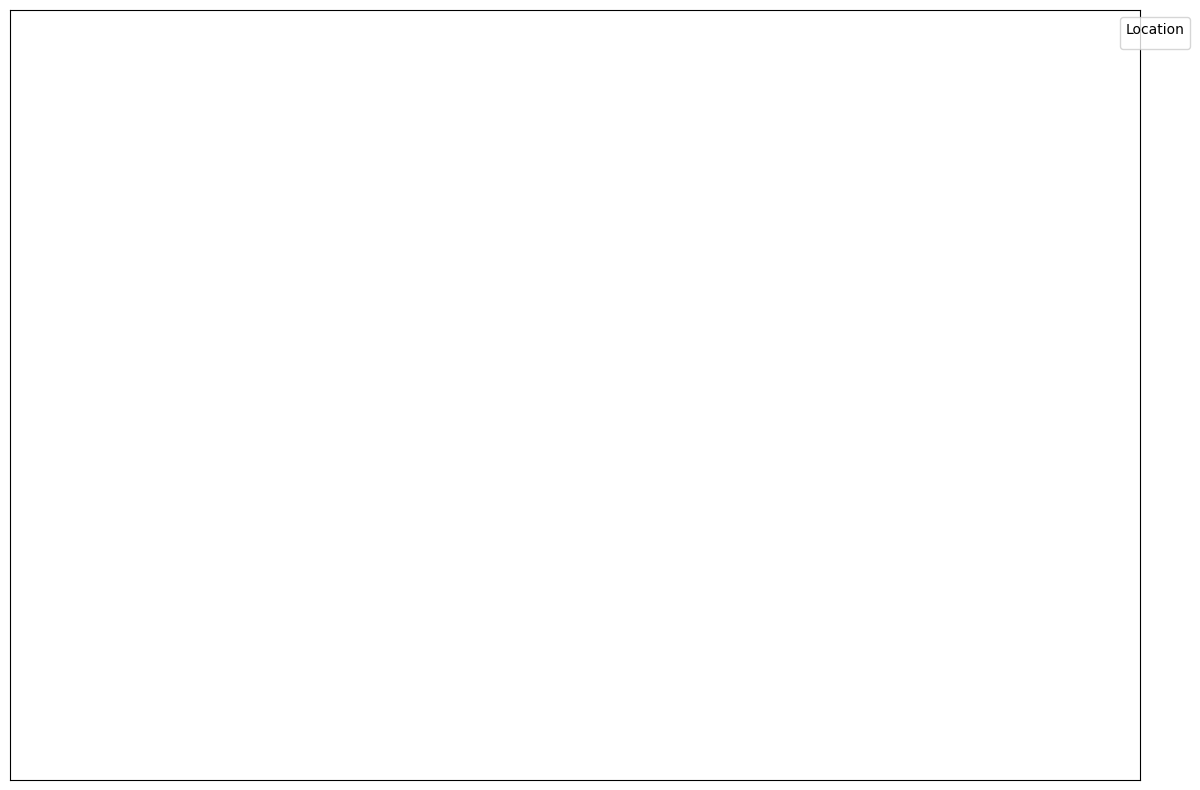

In [77]:
visualize_styles_with_locations(styles_with_locations(geo_proximity(artists_14c), artists_14c), "14th Century")

15 graph nodes found in artists dataframe


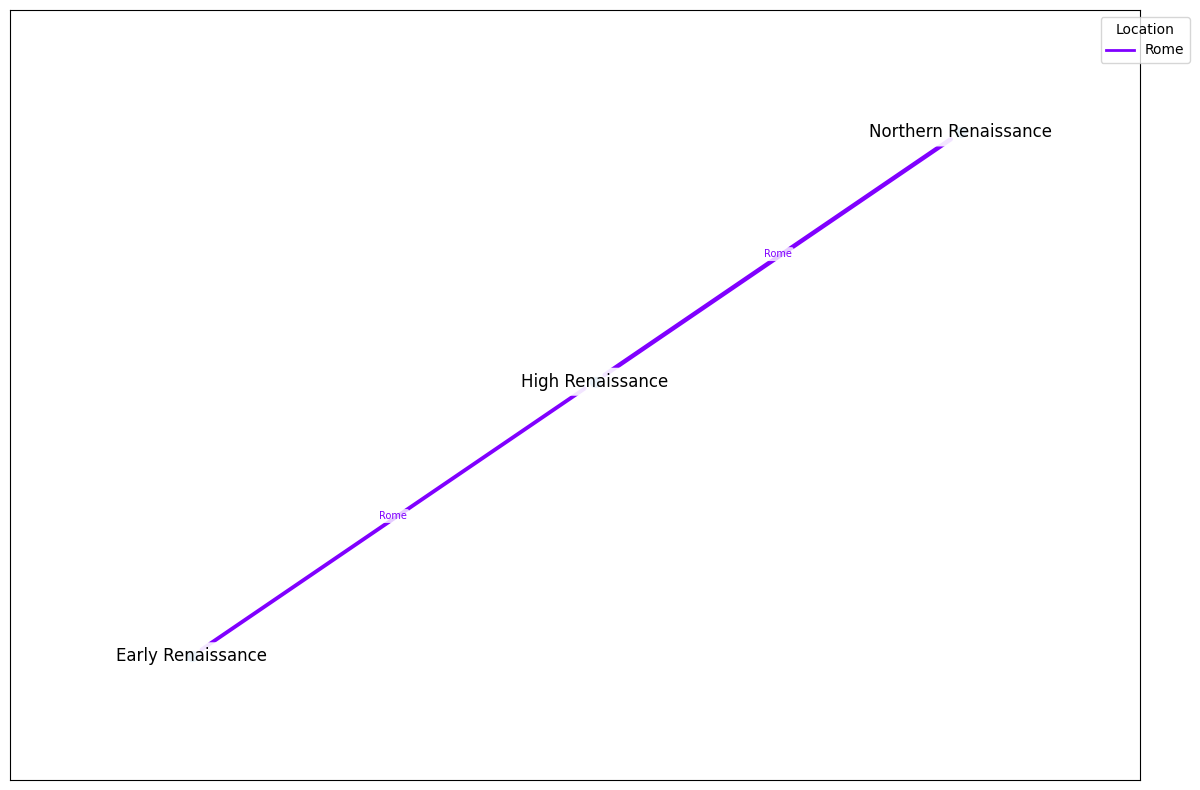

In [78]:
visualize_styles_with_locations(styles_with_locations(geo_proximity(artists_15c), artists_15c), "15th Century", True)

36 graph nodes found in artists dataframe


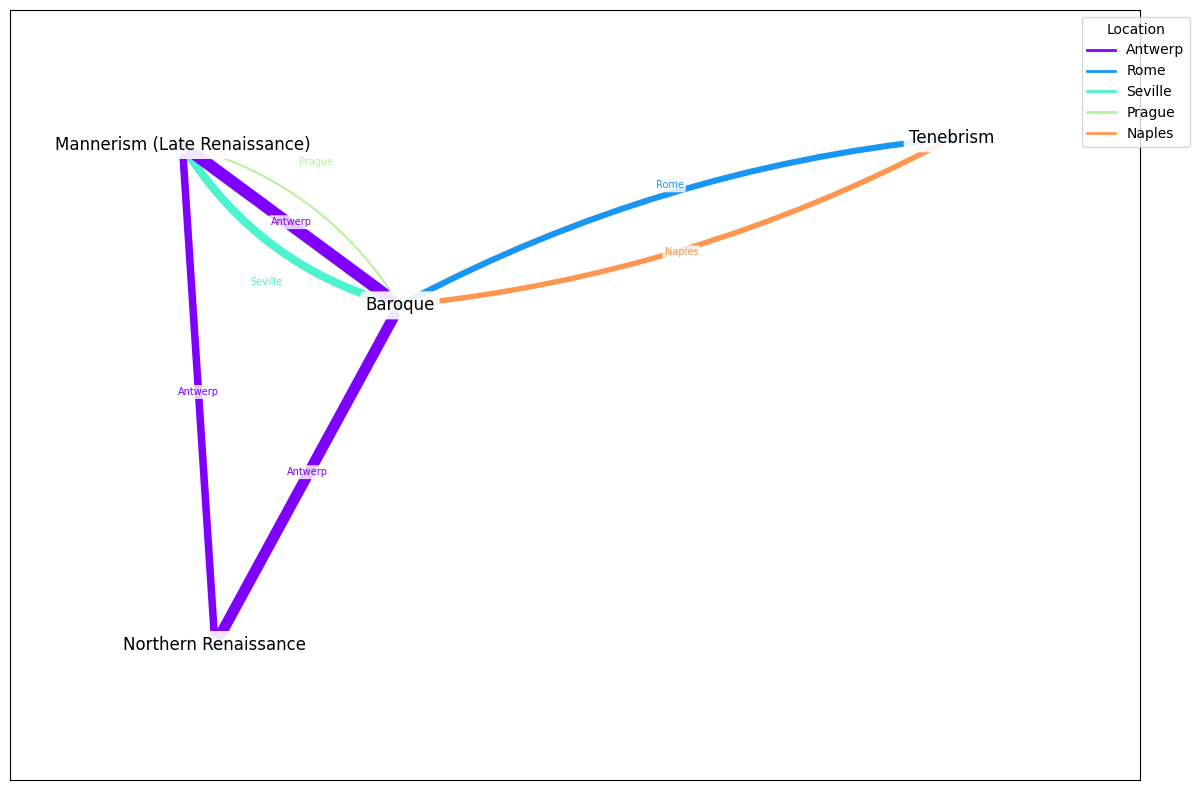

In [83]:
visualize_styles_with_locations(styles_with_locations(geo_proximity(artists_16c), artists_16c), "16th Century", True)

36 graph nodes found in artists dataframe


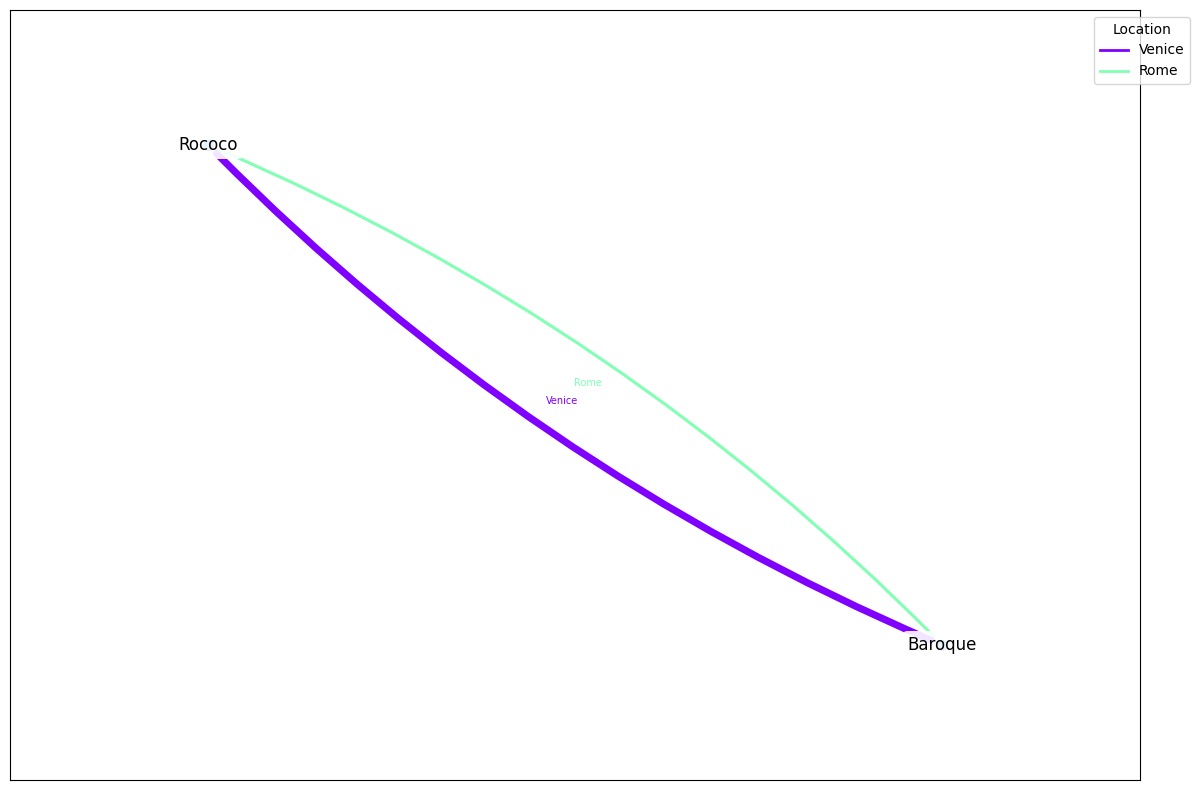

In [80]:
visualize_styles_with_locations(styles_with_locations(geo_proximity(artists_17c), artists_17c), "17th Century", True)

36 graph nodes found in artists dataframe


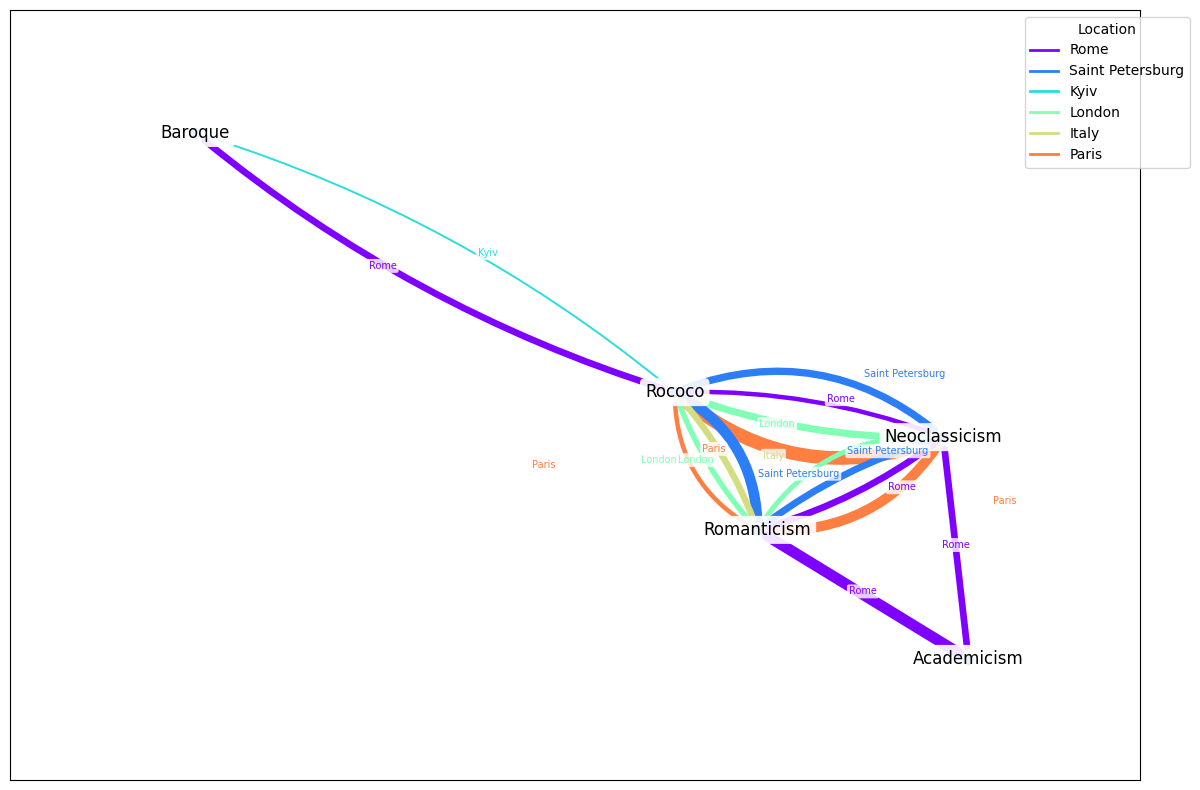

In [81]:
visualize_styles_with_locations(styles_with_locations(geo_proximity(artists_18c), artists_18c), "18th Century", True)

148 graph nodes found in artists dataframe


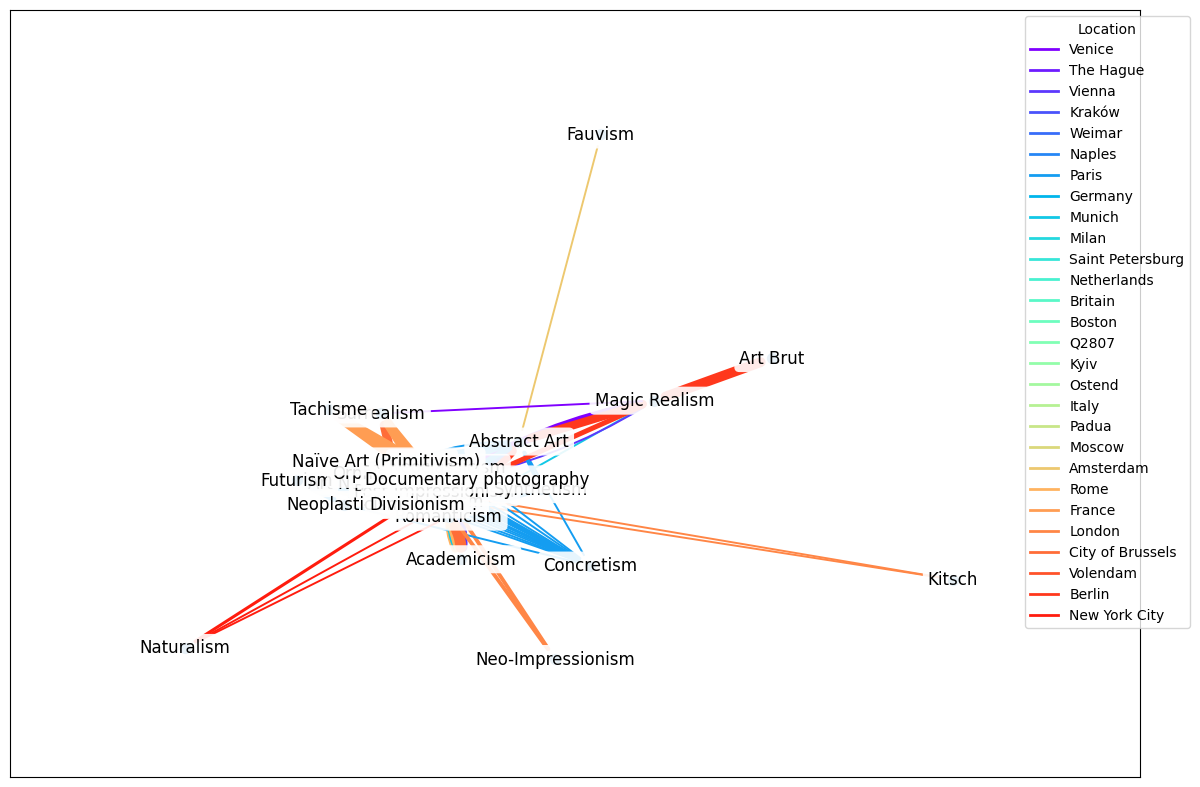

In [82]:
visualize_styles_with_locations(styles_with_locations(geo_proximity(artists_19c), artists_19c), "19th Century")

136 graph nodes found in artists dataframe


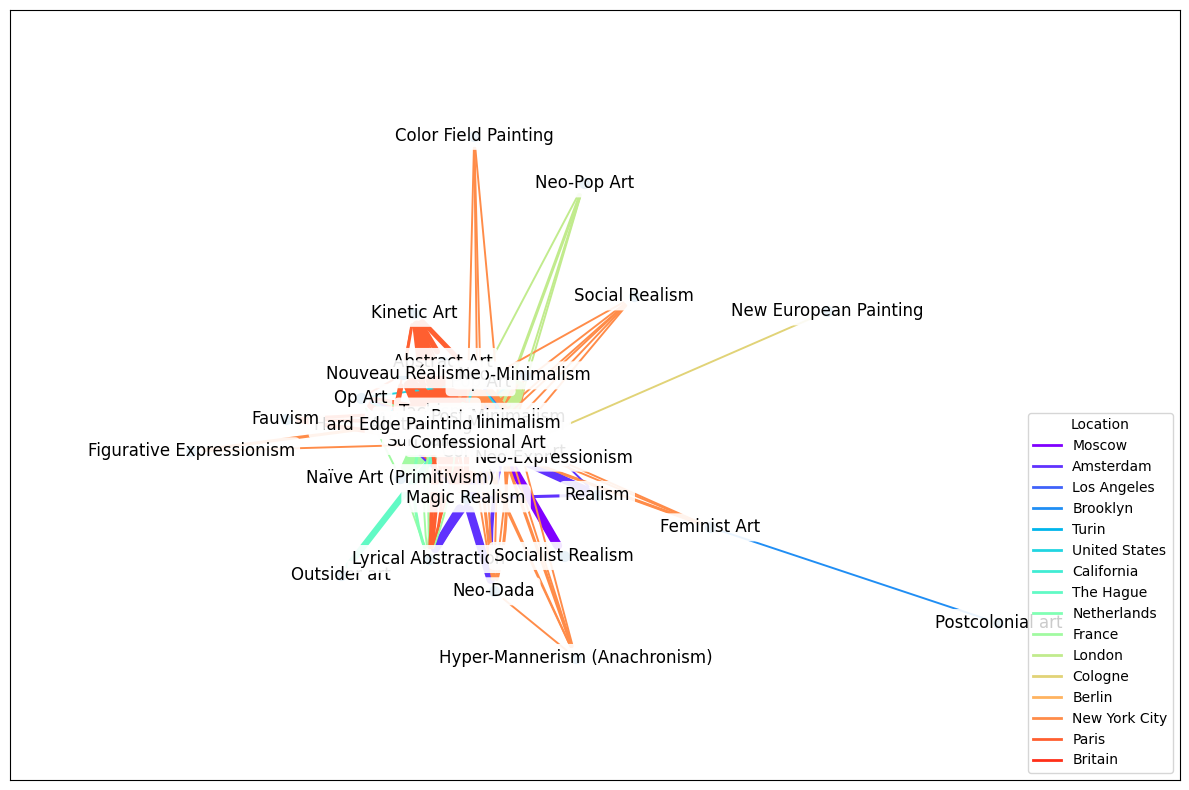

In [75]:
visualize_styles_with_locations(styles_with_locations(geo_proximity(artists_20c), artists_20c), "20th Century")